In [1]:
import jax.numpy as jnp
import jax
import numpy as np

from jax import config

config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
jax.default_backend()

'gpu'

In [3]:
np.random.seed(1)

In [4]:
def generate_gaussian_feature_matrix(n, k, theta):
    return (1 / np.sqrt(n + theta)) * jnp.asarray(np.random.randn(k, n))

In [5]:
def ReLU(z):
    return jnp.maximum(z,0)

def tanh(z):
    return jnp.tanh(z)

In [6]:
def data_generator(xi, gamma, m, n, theta, delta):
    A = jnp.asarray(np.random.randn(m, n))
    c = jnp.asarray(np.random.randn(m, 1))
    X = np.sqrt(theta) * c * gamma.reshape(1, n) + A
    epsilon = jnp.asarray(np.random.randn(m, 1))
    y = ReLU((1 / np.sqrt(1 + theta)) * X @ xi) + delta * epsilon
    return X, y

In [7]:
def loss(w, y, b, RF, l, lambd):
    return jnp.mean(l(y, RF.T@w + b)) + lambd * (jnp.linalg.norm(w) ** 2)

In [8]:
def l(y, z):
    return ((y-z)**2)

In [9]:
def least_square_estimator(y, b, RF, lambd):
    k, m = RF.shape
    w = jnp.linalg.inv(RF @ RF.T + lambd * m * jnp.eye(k)) @ RF @ (y - b)
    return w

In [10]:
z = np.random.randn(1000000)
rmu0 = ReLU(z).mean()
rmu1 = (z * ReLU(z)).mean()
rmu2 = (((z**2)-1) * ReLU(z)).mean()
rmu3 = (((z**3)-3*z) * ReLU(z)).mean()
rmus = np.sqrt((ReLU(z) ** 2).mean() - (rmu0**2) - (rmu1**2))
rmus3 = np.sqrt((ReLU(z) ** 2).mean() - (rmu0**2) - (rmu1**2) - (1/2)*(rmu2**2) - (1/6)*(rmu3**2))
tmu0 = tanh(z).mean()
tmu1 = (z * tanh(z)).mean()
tmu2 = (((z**2)-1) * tanh(z)).mean()
tmu3 = (((z**3)-3*z) * tanh(z)).mean()
tmus = np.sqrt((tanh(z) ** 2).mean() - (tmu0**2) - (tmu1**2))
tmus3 = np.sqrt((tanh(z) ** 2).mean() - (tmu0**2) - (tmu1**2) - (1/2)*(tmu2**2) - (1/6)*(tmu3**2))

In [11]:
rmu0, rmu1, rmu2, rmu3, rmus, rmus3, tmu0, tmu1, tmu2, tmu3, tmus, tmus3

(DeviceArray(0.39920748, dtype=float64),
 DeviceArray(0.49995747, dtype=float64),
 DeviceArray(0.39744188, dtype=float64),
 DeviceArray(-0.00527783, dtype=float64),
 0.3010537987018241,
 0.10792925045726842,
 DeviceArray(0.00038181, dtype=float64),
 DeviceArray(0.605473, dtype=float64),
 DeviceArray(0.00047198, dtype=float64),
 DeviceArray(-0.36635604, dtype=float64),
 0.16651959028195495,
 0.07320658806901056)

In [12]:
rho = 1
n = 400
m = 500
lambd = 1e-3
delta = 0
theta = np.sqrt(n)
NB_TRIALS = 50

In [13]:
xi = np.random.randn(n, 1)
xi *= rho / np.linalg.norm(xi)

gamma = np.copy(xi)

In [14]:
import gc,sys

def clear_caches():
    for module_name, module in sys.modules.items():
        if module_name.startswith("jax"):
            if module_name not in ["jax.interpreters.partial_eval"]:
                for obj_name in dir(module):
                    obj = getattr(module, obj_name)
                    if hasattr(obj, "cache_clear"):
                        try:
                            obj.cache_clear()
                        except:
                            pass
    gc.collect()

In [15]:
r_vals = [0.01, 0.1, 0.3, 0.4, 0.5, 0.7, 0.9, 1, 1.1, 1.5, 2, 3, 4, 5, 10]

relu_l_feature = np.zeros((len(r_vals), NB_TRIALS))
relu_gl_feature = np.zeros((len(r_vals), NB_TRIALS))
relu_l_gaussian = np.zeros((len(r_vals), NB_TRIALS))
relu_gl_gaussian = np.zeros((len(r_vals), NB_TRIALS))
relu_l_gaussian3 = np.zeros((len(r_vals), NB_TRIALS))
relu_gl_gaussian3 = np.zeros((len(r_vals), NB_TRIALS))

tanh_l_feature = np.zeros((len(r_vals), NB_TRIALS))
tanh_gl_feature = np.zeros((len(r_vals), NB_TRIALS))
tanh_l_gaussian = np.zeros((len(r_vals), NB_TRIALS))
tanh_gl_gaussian = np.zeros((len(r_vals), NB_TRIALS))
tanh_l_gaussian3 = np.zeros((len(r_vals), NB_TRIALS))
tanh_gl_gaussian3 = np.zeros((len(r_vals), NB_TRIALS))


def RFM(
    F, data, data_new, m, activation, mu0, mu1, mu2, mu3, mus, mus3, lambd=lambd, include_gaussian=False
):
    X, y = data
    X_new, y_new = data_new

    RF_feature = activation(F @ X.T)
    RF_feature_new = activation(F @ X_new.T)
    w_feature = least_square_estimator(y, 0, RF_feature, lambd)
    l_feature_ = loss(w_feature, y, 0, RF_feature, l, lambd)
    gl_feature_ = loss(w_feature, y_new, 0, RF_feature_new, l, 0)

    if include_gaussian:
        z = jnp.asarray(np.random.randn(k, m))
        z_new = jnp.asarray(np.random.randn(k, 5 * m))
        FX = F @ X.T
        FX2 = FX ** 2
        FX3 = FX ** 3
        RF_gaussian = mu0 + mu1 * FX + mus * z
        RF_gaussian3 = mu0 + mu1 * FX + (1/2) * mu2 * (FX2-1) + (1/6) * mu3 * (FX3 - 3*FX) + mus3 * z
        FXX = F @ X_new.T
        FXX2 = FXX ** 2
        FXX3 = FXX ** 3
        RF_gaussian_new = mu0 + mu1 * FXX + mus * z_new
        RF_gaussian_new3 = mu0 + mu1 * FXX + (1/2) * mu2 * (FXX2-1) + (1/6) * mu3 * (FXX3 - 3*FXX) + mus3 * z_new
        w_gaussian = least_square_estimator(y, 0, RF_gaussian, lambd)
        l_gaussian_ = loss(w_gaussian, y, 0, RF_gaussian, l, lambd)
        gl_gaussian_ = loss(w_gaussian, y_new, 0, RF_gaussian_new, l, 0)
        w_gaussian3 = least_square_estimator(y, 0, RF_gaussian3, lambd)
        l_gaussian_3 = loss(w_gaussian3, y, 0, RF_gaussian3, l, lambd)
        gl_gaussian_3 = loss(w_gaussian3, y_new, 0, RF_gaussian_new3, l, 0)

        return (
            l_feature_.item(),
            gl_feature_.item(),
            l_gaussian_.item(),
            gl_gaussian_.item(),
            l_gaussian_3.item(),
            gl_gaussian_3.item(),
        )
    else:
        return (l_feature_.item(), gl_feature_.item())



for e in tqdm(range(NB_TRIALS)):
    for r_i, r in enumerate(tqdm(r_vals)):
        k = int(m * r)
        F = generate_gaussian_feature_matrix(n, k, theta)
        data = data_generator(xi, gamma, m, n, theta, delta)
        data_new = data_generator(xi, gamma, 5 * m, n, theta, delta)
        
        (
            relu_l_feature[r_i, e],
            relu_gl_feature[r_i, e],
            relu_l_gaussian[r_i, e],
            relu_gl_gaussian[r_i, e],
            relu_l_gaussian3[r_i, e],
            relu_gl_gaussian3[r_i, e],
        ) = RFM(
            F,
            data,
            data_new,
            m,
            ReLU,
            rmu0,
            rmu1,
            rmu2,
            rmu3,
            rmus,
            rmus3,
            lambd=lambd,
            include_gaussian=True,
        )
        (
            tanh_l_feature[r_i, e],
            tanh_gl_feature[r_i, e],
            tanh_l_gaussian[r_i, e],
            tanh_gl_gaussian[r_i, e],
            tanh_l_gaussian3[r_i, e],
            tanh_gl_gaussian3[r_i, e],
        ) = RFM(
            F,
            data,
            data_new,
            m,
            tanh,
            tmu0,
            tmu1,
            tmu2,
            tmu3,
            tmus,
            tmus3,
            lambd=lambd,
            include_gaussian=True,
        )

        clear_caches()

In [18]:
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)

plt.style.use(["science", "bright"])
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times"],
        "font.size": 10,
        "figure.dpi": "600",
    }
)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

(0.005, 1.8)

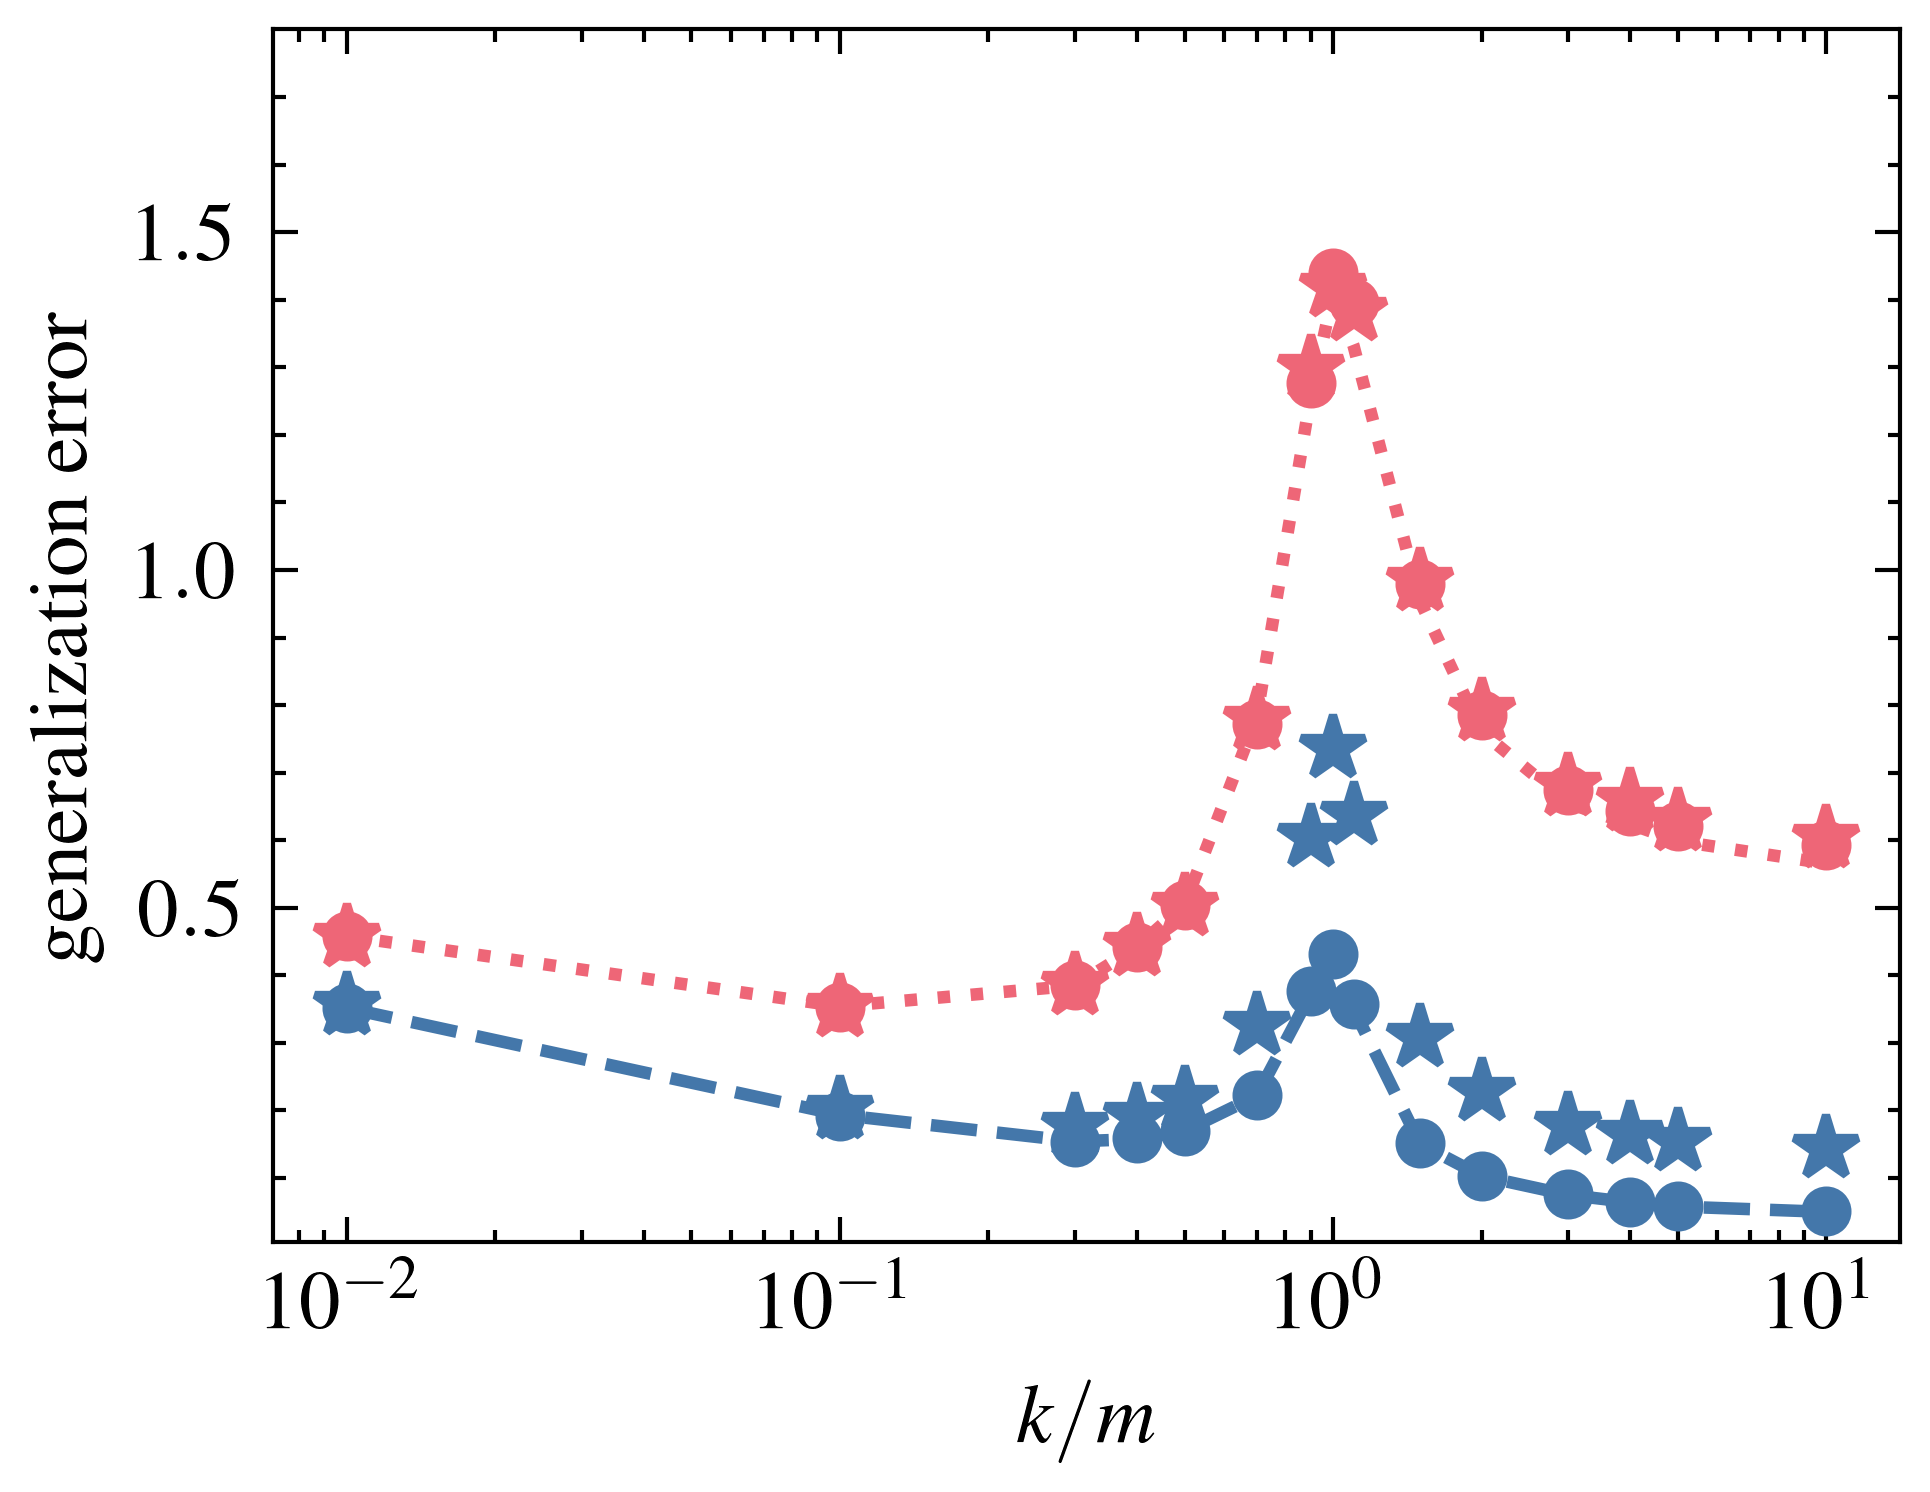

In [21]:
from matplotlib.legend_handler import HandlerTuple

plt.figure()
(relu_feature_gen,) = plt.plot(
    r_vals,
    np.mean(relu_gl_feature, axis=1),
    color=colors[0],
    linestyle="None",
    marker="o",
    markersize=5,
)
(relu_gaussian_gen,) = plt.plot(
    r_vals,
    np.mean(relu_gl_gaussian, axis=1),
    color=colors[0],
    linestyle="None",
    marker="*",
    markersize=8,
)

(relu_gaussian_gen3,) = plt.plot(
    r_vals,
    np.mean(relu_gl_gaussian3, axis=1),
    color=colors[0],
    linestyle="dashed",
    linewidth=1.5,
    label="ReLU",
)

(tanh_feature_gen,) = plt.plot(
    r_vals,
    np.mean(tanh_gl_feature, axis=1),
    color=colors[1],
    linestyle="None",
    marker="o",
    markersize=5,
)
(tanh_gaussian_gen,) = plt.plot(
    r_vals,
    np.mean(tanh_gl_gaussian, axis=1),
    color=colors[1],
    linestyle="None",
    marker="*",
    markersize=8,
)
(tanh_gaussian_gen3,) = plt.plot(
    r_vals,
    np.mean(tanh_gl_gaussian3, axis=1),
    color=colors[1],
    linestyle="dotted",
    linewidth=1.5,
    label="tanh",
)
plt.xlabel(r"$k/m$")
plt.ylabel(r"generalization error")
plt.xscale("log")
plt.ylim(0.005, 1.8)

# legend1 = plt.legend(
#     [(relu_feature_gen), (tanh_feature_gen)],
#     ["ReLU", "tanh"],
#     loc=1,
#     handler_map={tuple: HandlerTuple(ndivide=None)},
# )
# legend2 = plt.legend(
#     [
#         (relu_feature_gen, tanh_feature_gen),
#         (relu_gaussian_gen, tanh_gaussian_gen),
#         (relu_gaussian_gen3, tanh_gaussian_gen3),
#     ],
#     [
#         "Random Feature Model",
#         "Noisy Linear Model",
#         "Noisy Polynomial Model",
#     ],
#     loc=2,
#     handler_map={tuple: HandlerTuple(ndivide=None)},
# )
# plt.gca().add_artist(legend1)

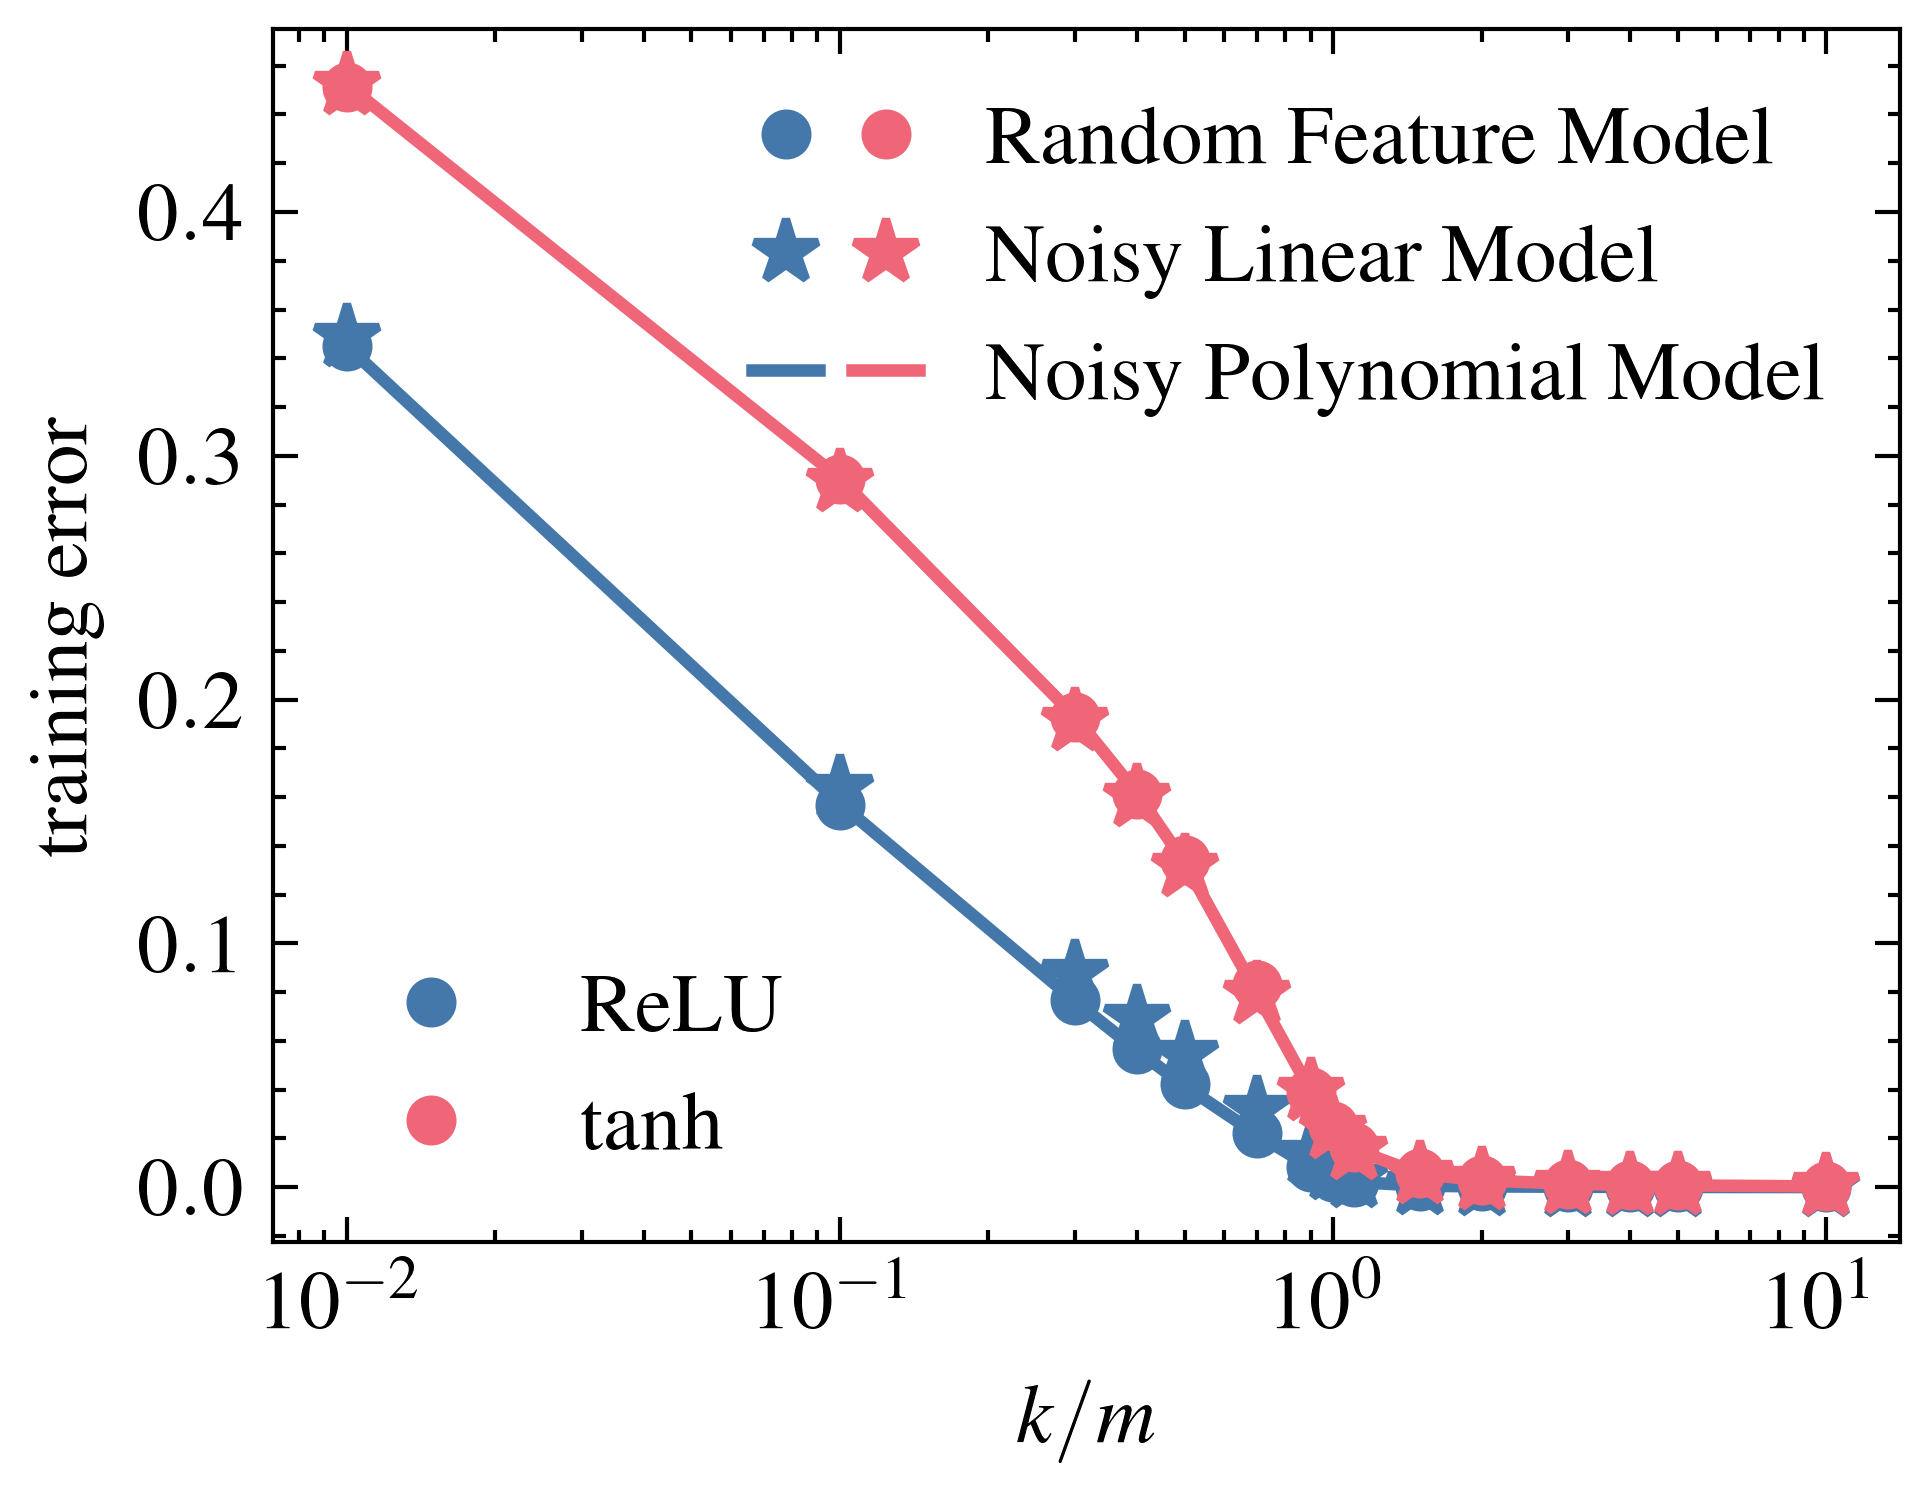

In [22]:
from matplotlib.legend_handler import HandlerTuple

plt.figure()
(relu_feature,) = plt.plot(
    r_vals,
    np.mean(relu_l_feature, axis=1),
    color=colors[0],
    linestyle="None",
    marker="o",
    markersize=5,
)
(relu_gaussian,) = plt.plot(
    r_vals,
    np.mean(relu_l_gaussian, axis=1),
    color=colors[0],
    linestyle="None",
    marker="*",
    markersize=8,
)
(relu_gaussian3,) = plt.plot(
    r_vals,
    np.mean(relu_l_gaussian3, axis=1),
    color=colors[0],
    linewidth=1.5,
    linestyle="solid",
)

(tanh_feature,) = plt.plot(
    r_vals,
    np.mean(tanh_l_feature, axis=1),
    color=colors[1],
    linestyle="None",
    marker="o",
    markersize=5,
)
(tanh_gaussian,) = plt.plot(
    r_vals,
    np.mean(tanh_l_gaussian, axis=1),
    color=colors[1],
    linestyle="None",
    marker="*",
    markersize=8,
)
(tanh_gaussian3,) = plt.plot(
    r_vals,
    np.mean(tanh_l_gaussian3, axis=1),
    color=colors[1],
    linewidth=1.5,
    linestyle="solid",
)

plt.xlabel(r"$k/m$")
plt.ylabel(r"training error")
plt.xscale("log")

legend1 = plt.legend(
    [(relu_feature), (tanh_feature)],
    ["ReLU", "tanh"],
    loc=3,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
legend2 = plt.legend(
    [
        (relu_feature, tanh_feature),
        (relu_gaussian, tanh_gaussian),
        (relu_gaussian3, tanh_gaussian3),
    ],
    [
        "Random Feature Model",
        "Noisy Linear Model",
        "Noisy Polynomial Model",
    ],
    loc=1,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)
plt.gca().add_artist(legend1)